### 03. 전처리·공간기반 구축 (P2)

원본을 canonical 표로 정제하고(H02), 창원시 경계와 100m 분석격자를 만든다(H03).
정제 함수를 직접 불러 중간 결과를 확인한다. 파이프라인 노드가 같은 함수를 쓴다.
원본은 수정하지 않고, 오류 행은 원행 번호·사유와 함께 격리한다.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.pipeline.graph import Graph
from src.pipeline import manifest as mf
from src.pipeline.report import node_metrics, node_table

GRAPH = Graph.load()

import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import Image

from src.visualization import style

style.apply()

from src.data import normalize, sgis, spatial

RAW = ROOT / 'data/raw'

### 강수 정제 실행

하네스 §6-1 의 규칙 R01~R05 를 적용한다. 값을 임의로 0 으로 바꾸지 않는다.

In [2]:
rain_path = next(RAW.glob("*시간별 강수량*.csv"))
rain_canonical, rain_quarantine, rain_metrics = normalize.clean_rainfall(rain_path)

print(f"원본 {rain_metrics['rows_in']:,} = 정제 {rain_metrics['rows_out_wide']:,} + 격리 {rain_metrics['rows_quarantined']:,}")
print(f"행수 보존식 {rain_metrics['row_identity_ok']} · 정제 후 키 중복 {rain_metrics['duplicate_keys_after_clean']}건")
print(f"cohort {rain_metrics['stations_in_cohort']}개 지점")

원본 173,740 = 정제 171,614 + 격리 2,126
행수 보존식 True · 정제 후 키 중복 0건
cohort 29개 지점


### 격리 규칙별 건수

R01 완전중복 · R02 값이 다른 충돌행(자동 선택 금지) · R03 존재하지 않는 날짜 ·
R04 음수/300mm 초과 셀(0 치환 금지) · R05 2000년 이전

In [3]:
pd.DataFrame([{"규칙": k, "건수": v} for k, v in rain_metrics["quarantine_by_rule"].items()])

,규칙,건수
0,H02-R01,2067
1,H02-R02,47
2,H02-R03,3
3,H02-R04,145
4,H02-R05,9


### 격리된 원본 행

원본 행 번호와 사유가 남아 나중에 되짚을 수 있다.

In [4]:
rain_quarantine.head(8)

,source_file,source_row,station_id,date,reason,detail
0,경상남도 창원시_시간별 강수량_20250923.csv,43370,32,2014-02-19,H02-R01,"완전중복 행, 첫 행만 유지"
1,경상남도 창원시_시간별 강수량_20250923.csv,43465,6,2014-02-23,H02-R01,"완전중복 행, 첫 행만 유지"
2,경상남도 창원시_시간별 강수량_20250923.csv,43487,35,2014-02-23,H02-R01,"완전중복 행, 첫 행만 유지"
3,경상남도 창원시_시간별 강수량_20250923.csv,43489,36,2014-02-23,H02-R01,"완전중복 행, 첫 행만 유지"
4,경상남도 창원시_시간별 강수량_20250923.csv,43790,28,2014-03-06,H02-R01,"완전중복 행, 첫 행만 유지"
5,경상남도 창원시_시간별 강수량_20250923.csv,43794,31,2014-03-06,H02-R01,"완전중복 행, 첫 행만 유지"
6,경상남도 창원시_시간별 강수량_20250923.csv,103715,1,2019-10-14,H02-R01,"완전중복 행, 첫 행만 유지"
7,경상남도 창원시_시간별 강수량_20250923.csv,116424,50,2020-12-04,H02-R01,"완전중복 행, 첫 행만 유지"


### 정제 결과

wide 24개 시각 컬럼이 시각별 한 행으로 펴진다.

In [5]:
rain_canonical.head(5)

,station_id,station_name,observed_at,hour_label,rainfall_mm,quality_flag,source_file,source_row,cleaning_rule
0,28,진해구청,2005-01-01 01:00:00,1시강수량,2.5,ok,경상남도 창원시_시간별 강수량_20250923.csv,9,H02-R01..R05
1,28,진해구청,2005-01-01 02:00:00,2시강수량,0.0,ok,경상남도 창원시_시간별 강수량_20250923.csv,9,H02-R01..R05
2,28,진해구청,2005-01-01 03:00:00,3시강수량,0.0,ok,경상남도 창원시_시간별 강수량_20250923.csv,9,H02-R01..R05
3,28,진해구청,2005-01-01 04:00:00,4시강수량,0.0,ok,경상남도 창원시_시간별 강수량_20250923.csv,9,H02-R01..R05
4,28,진해구청,2005-01-01 05:00:00,5시강수량,0.0,ok,경상남도 창원시_시간별 강수량_20250923.csv,9,H02-R01..R05


### 하천수위 정제

센티널(-47999, -8383, 9321, 9999)은 실제 수위가 아니므로 level_cm 에서 빼고
raw_value 에 원값을 남긴다.

In [6]:
river_path = next(RAW.glob("*하천수위*.csv"))
river_canonical, river_quarantine, river_metrics = normalize.clean_river(river_path)

print(f"센티널 {river_metrics['sentinel_cells']:,}셀 · 물리범위 밖 {river_metrics['out_of_range_cells']}셀")
print(f"정제값에 남은 센티널 {river_metrics['sentinel_values_in_level']}건")
pd.DataFrame([{"지점": k, "유효일 커버리지": v} for k, v in river_metrics["valid_day_coverage_by_station"].items()])

센티널 15,187셀 · 물리범위 밖 18셀
정제값에 남은 센티널 0건


,지점,유효일 커버리지
0,8,0.8541
1,50,0.0249


### SGIS 통계 표준화

헤더가 없는 CSV 라 계약이 정한 4개 컬럼을 코드에서 부여한다.

In [7]:
grid_paths = sorted((RAW / "sgis/grid_statistics_100m_2024").glob("*.csv"))
grid_stats, grid_meta = sgis.load_group(grid_paths, "cp949")

print(f"{grid_meta['files']}개 파일 · {grid_meta['rows']:,}행 · 키 중복 {grid_meta['duplicate_keys']}")
print(f"고유 격자 {grid_meta['unique_spatial_ids']:,}개")
grid_meta["variable_labels"]

12개 파일 · 1,224,893행 · 키 중복 0
고유 격자 251,936개


{'to_ga_001': '총가구',
 'to_ho_001': '총주택',
 'to_in_001': '총인구',
 'to_in_007': '남자인구',
 'to_in_008': '여자인구'}

In [8]:
grid_stats.head(5)

,year,spatial_id,variable,value,source_file,source_row
0,2024,라라000072,to_ga_001,0,2024년_가구_라라_100M.csv,0
1,2024,라라000073,to_ga_001,5,2024년_가구_라라_100M.csv,1
2,2024,라라000074,to_ga_001,5,2024년_가구_라라_100M.csv,2
3,2024,라라000400,to_ga_001,15,2024년_가구_라라_100M.csv,3
4,2024,라라000401,to_ga_001,5,2024년_가구_라라_100M.csv,4


### 창원시 경계 파생

행정경계를 따로 받지 않고, 보유한 SGIS 집계구 경계를 행정동 코드로 합쳐 만든다.

In [9]:
agg_paths = sorted((RAW / "sgis/aggregation_boundaries_2025_2Q").glob("*.shp"))
layers, boundary_metrics = spatial.build_boundary(agg_paths)

print(f"집계구 {boundary_metrics['n_aggregation_units']:,} → 행정동 {boundary_metrics['n_emd']} · 구 {boundary_metrics['n_gu']}")
print(f"면적 {boundary_metrics['area_km2']} km² (공식 {spatial.CHANGWON_AREA_KM2} km² 대비 {boundary_metrics['area_ratio_vs_official']:.2%})")
print(f"구 겹침 {boundary_metrics['gu_overlap_m2']} m² · invalid 수정 {boundary_metrics['invalid_fixed']}건")

집계구 2,118 → 행정동 55 · 구 5
면적 754.42 km² (공식 748.0 km² 대비 100.86%)
구 겹침 1.697 m² · invalid 수정 0건


### 경계 확인

해안선과 섬이 빠지지 않았는지 눈으로 본다 (사람 검수 항목).

findfont: Failed to find font weight bold, now using 400.


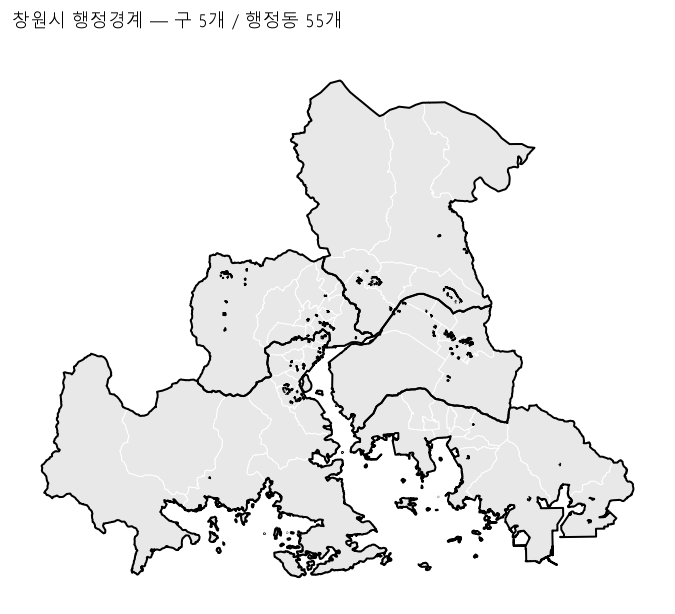

In [10]:
gu, emd = layers["gu"], layers["emd"]

fig, ax = plt.subplots(figsize=(7, 7))
emd.plot(ax=ax, facecolor=style.PALE, edgecolor="white", linewidth=0.6)
gu.boundary.plot(ax=ax, color=style.INK, linewidth=1.2)
ax.set_title(f"창원시 행정경계 — 구 {len(gu)}개 / 행정동 {len(emd)}개", loc="left")
ax.set_axis_off()
plt.show()

### 100m 분석격자

전국 도엽에서 중심점이 창원 안에 드는 격자만 고른다. 격자를 자르면 면적이 달라져
격자 단위 통계와 맞지 않기 때문에 자르지 않는다. (약 30초 소요)

In [11]:
tile_paths = sorted((RAW / "sgis/grid_boundaries_100m_2025").glob("*.shp"))
grid, grid_base_metrics = spatial.select_grid_in_boundary(tile_paths, layers["si"], emd)

print(f"도엽 bbox {grid_base_metrics['n_in_bbox']:,} → 창원 격자 {grid_base_metrics['n_grid']:,}개")
print(f"grid_id 중복 {grid_base_metrics['duplicate_grid_id']} · 행정동 미배정 {grid_base_metrics['n_without_emd']}")

도엽 bbox 155,262 → 창원 격자 75,400개
grid_id 중복 0 · 행정동 미배정 0


### 격자에 인구 붙이기

인구는 소수 격자에 몰려 있어 선형 스케일이면 대부분 흰색으로 보인다. 로그로 그린다.

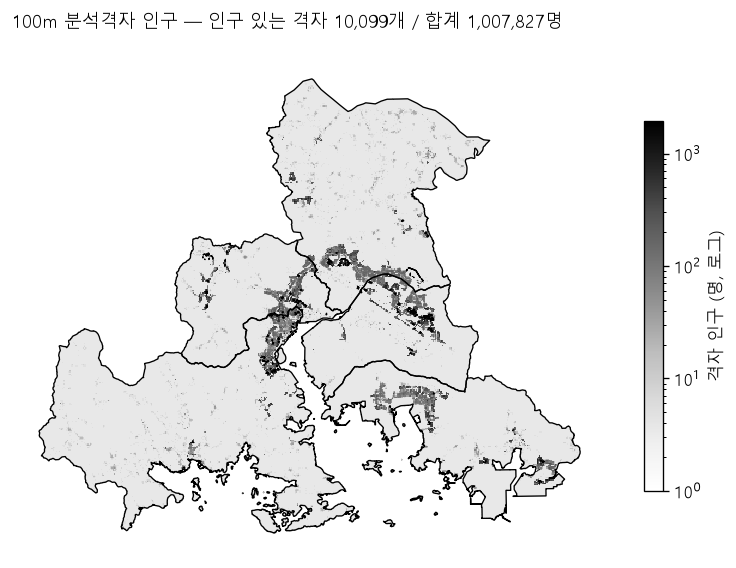

In [12]:
from matplotlib.colors import LogNorm

pop = (grid_stats[grid_stats["variable"] == "to_in_001"][["spatial_id", "value"]]
       .rename(columns={"spatial_id": "grid_id", "value": "population"}))
grid = grid.merge(pop, on="grid_id", how="left")
populated = grid[grid["population"] > 0]

fig, ax = plt.subplots(figsize=(8, 8))
grid.plot(ax=ax, color=style.PALE, linewidth=0)
populated.plot(ax=ax, column="population", cmap="Greys", linewidth=0, legend=True,
               norm=LogNorm(vmin=1, vmax=populated["population"].max()),
               legend_kwds={"label": "격자 인구 (명, 로그)", "shrink": 0.5})
gu.boundary.plot(ax=ax, color=style.INK, linewidth=0.8)
ax.set_title(f"100m 분석격자 인구 — 인구 있는 격자 {len(populated):,}개 / 합계 {grid['population'].sum():,.0f}명", loc="left")
ax.set_axis_off()
plt.show()

### 파이프라인 실행 결과와 대조

노트북에서 직접 계산한 값과 노드 실행 기록이 같아야 한다.

In [13]:
checks = [
    ("h02_rainfall_long", "rows_quarantined", rain_metrics["rows_quarantined"]),
    ("h02_rainfall_long", "stations_in_cohort", rain_metrics["stations_in_cohort"]),
    ("h02_river_long", "sentinel_cells", river_metrics["sentinel_cells"]),
    ("h03_boundary", "n_emd", boundary_metrics["n_emd"]),
    ("h03_grid_base", "n_grid", grid_base_metrics["n_grid"]),
]
for node_id, key, here in checks:
    there = node_metrics(node_id)[key]
    print(f"{node_id:20} {key:20} 노트북 {here:>9,}  파이프라인 {there:>9,}  {'일치' if here == there else '불일치'}")

h02_rainfall_long    rows_quarantined     노트북     2,126  파이프라인     2,126  일치


h02_rainfall_long    stations_in_cohort   노트북        29  파이프라인        29  일치
h02_river_long       sentinel_cells       노트북    15,187  파이프라인    15,187  일치


h03_boundary         n_emd                노트북        55  파이프라인        55  일치
h03_grid_base        n_grid               노트북    75,400  파이프라인    75,400  일치


### 아직 막힌 노드

| 노드 | 필요한 것 |
|---|---|
| 관측지점 좌표 결합 | 강수 29지점 좌표 (접근신청 #7·#9) |
| 펌프장 지오코딩·검수 | 주소 지오코딩 + 사람 검수 (#10·#11) |
| 격자 피처 결합 | 위 둘 + DEM 경사·TWI, 토지피복 불투수면 |

좌표가 확보되면 `--only h03_stations` 부터 이어서 실행한다. 통과한 노드는 캐시로 건너뛴다.